# Gradient Descent from Scratch
by AI@UCI

** ENSURE YOU ARE RUNNING THIS IN AN ENVIRONMENT WITH THE REQUIRED PACKAGES **

## Introduction to Gradient Descent

Gradient Descent is an optimization algorithm that:

- Finds the minimum of a function by iteratively moving in the direction of steepest descent
- Is the foundation of most machine learning training algorithms
- Uses derivatives (gradients) to determine the direction to move
- Adjusts parameters step by step to minimize a cost/loss function

We'll implement:
- Linear regression using gradient descent
- Mean Squared Error (MSE) cost function
- Batch gradient descent algorithm
- Visualization of the optimization process


In [1]:
! pip install numpy pandas matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Loading the Dataset


In [11]:
# Load the dataset
DATA_CSV = "../datasets/gradient_descent_data.csv"
df = pd.read_csv(DATA_CSV)
df.head()


,feature,target
0,0.00000,3.496714
1,0.10101,3.063756
2,0.20202,4.051729
3,0.30303,5.129090
4,0.40404,3.573927


In [12]:
# Separate features and target
X = df[['feature']].values
y = df['target'].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(f"Dataset size: {len(X)} samples")


Features shape: (100, 1)
Target shape: (100,)
Dataset size: 100 samples


## Visualizing the Data


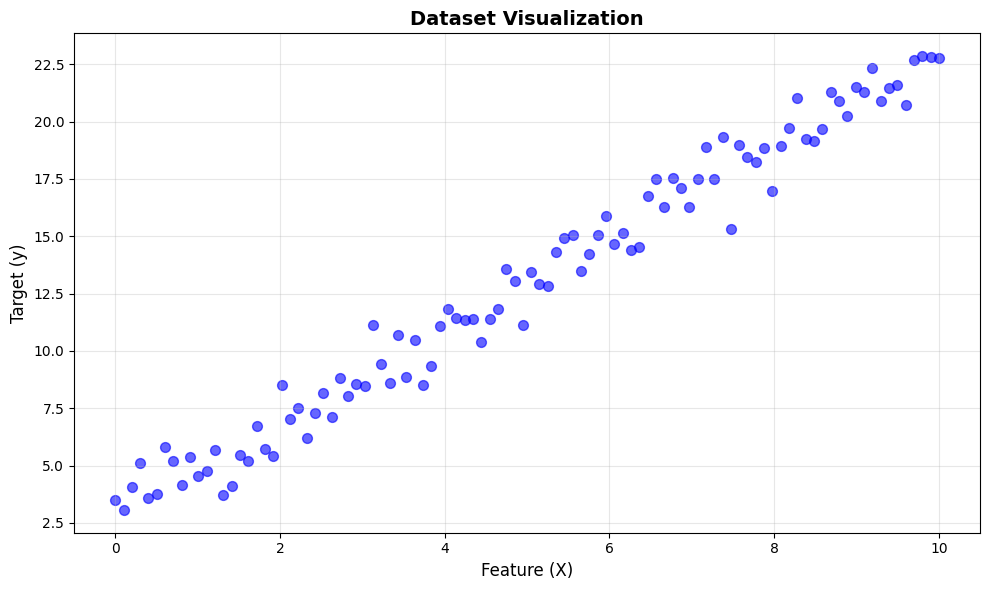

In [22]:
# Plot the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='blue', s=50)
plt.xlabel('Feature (X)', fontsize=12)
plt.ylabel('Target (y)', fontsize=12)
plt.title('Dataset Visualization', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Gradient Descent Implementation


In [23]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        """
        Initialize Linear Regression with Gradient Descent.
        
        Parameters:
        learning_rate: Step size for gradient descent
        max_iterations: Maximum number of iterations
        tolerance: Convergence threshold
        """
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        """Train the model using gradient descent."""
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []
        
        # Gradient descent loop
        for i in range(self.max_iterations):
            # Predictions
            y_pred = X.dot(self.weights) + self.bias
            
            # Calculate cost (MSE)
            cost = np.mean((y_pred - y) ** 2)
            self.cost_history.append(cost)
            
            # Calculate gradients
            dw = (2 / n_samples) * X.T.dot(y_pred - y)
            db = (2 / n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Check for convergence
            if i > 0 and abs(self.cost_history[-2] - self.cost_history[-1]) < self.tolerance:
                print(f"Converged after {i+1} iterations")
                break
        
        return self

    def predict(self, X):
        """Make predictions."""
        return X.dot(self.weights) + self.bias

    def score(self, X, y):
        """Calculate R-squared score."""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)


## Training the Model


In [24]:
# Train the model
model = LinearRegressionGD(learning_rate=0.003, max_iterations=400)
model.fit(X, y)

print(f"Learned weights: {model.weights}")
print(f"Learned bias: {model.bias:.4f}")
print(f"Final cost: {model.cost_history[-1]:.4f}")
print(f"R-squared score: {model.score(X, y):.4f}")


Learned weights: [2.21829082]
Learned bias: 1.4671
Final cost: 1.2858
R-squared score: 0.9636


## Visualizing the Results


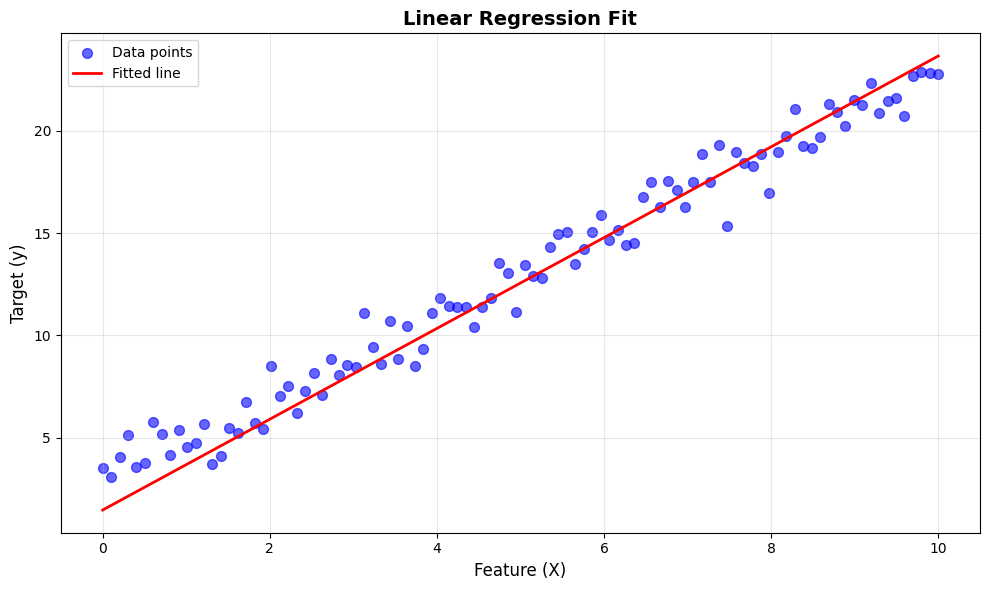

In [25]:
# Plot the data and fitted line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='blue', s=50, label='Data points')
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, 'r-', linewidth=2, label='Fitted line')
plt.xlabel('Feature (X)', fontsize=12)
plt.ylabel('Target (y)', fontsize=12)
plt.title('Linear Regression Fit', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


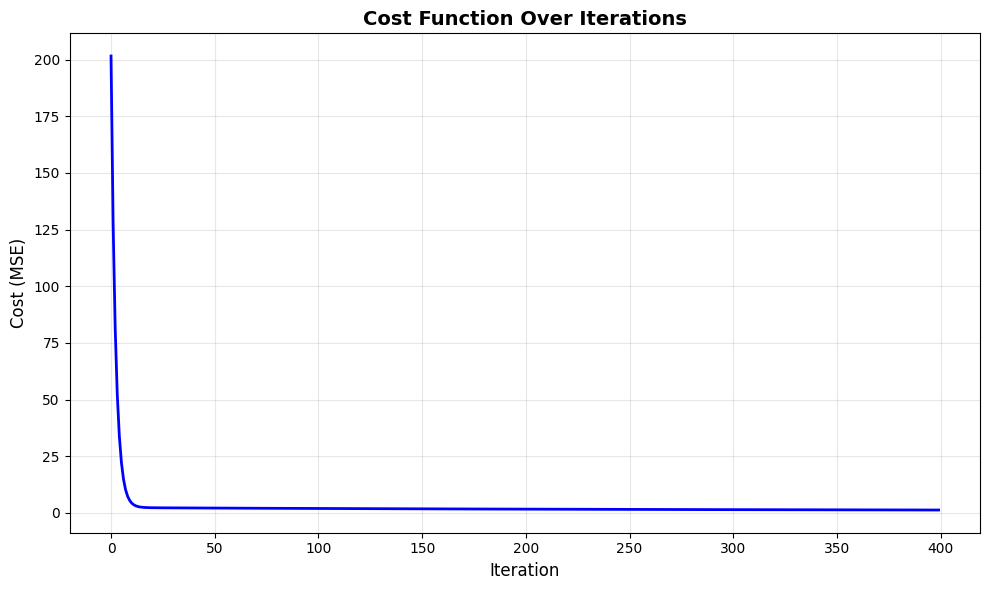

In [26]:
# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(range(len(model.cost_history)), model.cost_history, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.title('Cost Function Over Iterations', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Testing Different Learning Rates


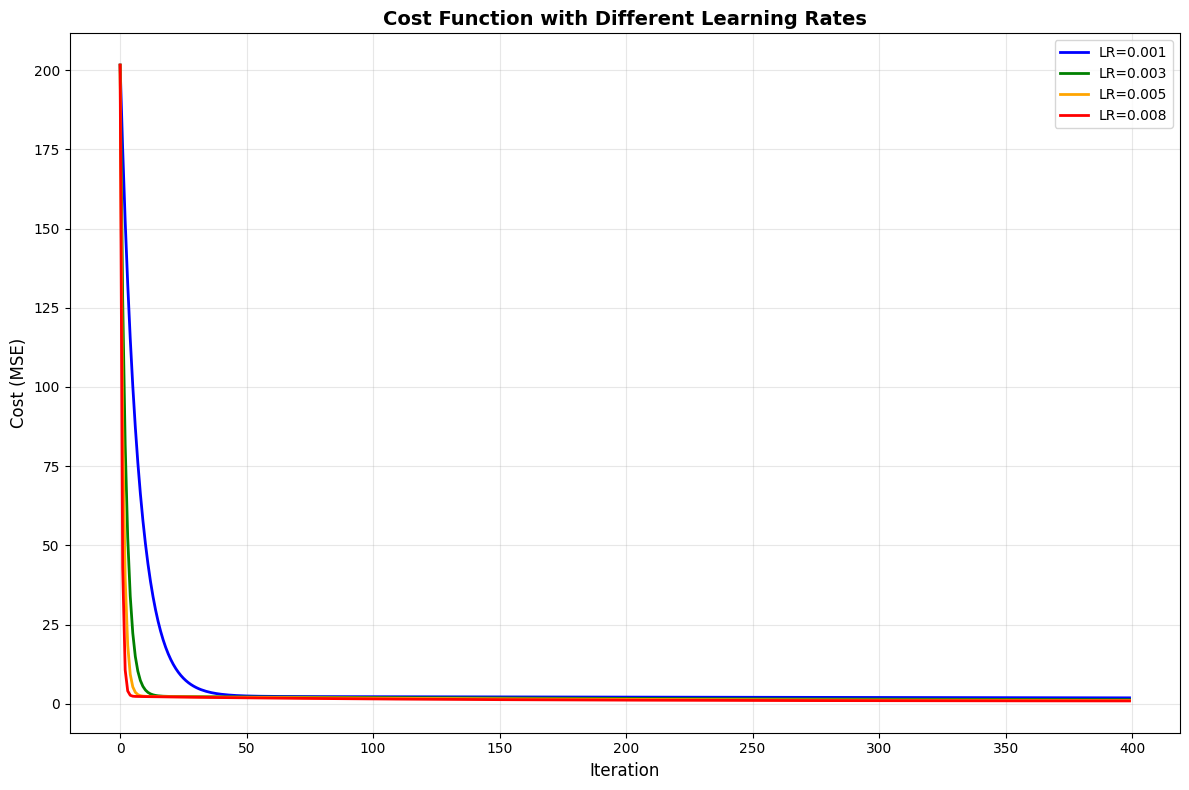

In [27]:
# Test different learning rates
learning_rates = [0.001, 0.003, 0.005, 0.008]
colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(12, 8))
for lr, color in zip(learning_rates, colors):
    model_test = LinearRegressionGD(learning_rate=lr, max_iterations=400)
    model_test.fit(X, y)
    plt.plot(range(len(model_test.cost_history)), model_test.cost_history, 
             color=color, linewidth=2, label=f'LR={lr}')
    
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.title('Cost Function with Different Learning Rates', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

In this notebook, we successfully implemented Gradient Descent from scratch and applied it to linear regression. Key takeaways:

1. **Gradient Descent finds optimal parameters** - it iteratively updates weights and bias to minimize cost
2. **Learning rate is critical** - too small and convergence is slow, too large and it may diverge
3. **Cost function decreases over iterations** - we can visualize the optimization process
4. **MSE measures prediction error** - lower MSE means better fit
5. **Convergence can be monitored** - we stop when cost changes are minimal

The implementation demonstrates the core optimization algorithm used in most machine learning training procedures, from simple linear models to deep neural networks.
